Brian Kassin **"On my honor, as a student, I have neither given nor received unauthorized aid on this academic work."**

In [119]:
# Imported Libraries

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import collections
import time

from sklearn.metrics import classification_report, precision_recall_curve, confusion_matrix, auc, precision_recall_fscore_support
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, average_precision_score
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.utils.fixes import signature
from sklearn.externals import joblib
from sklearn.manifold import TSNE
from sklearn.svm import SVC

from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline
from imblearn.metrics import classification_report_imbalanced
from imblearn.under_sampling import NearMiss
from imblearn.datasets import fetch_datasets
from imblearn.over_sampling import SMOTE

from collections import Counter

import warnings
warnings.filterwarnings("ignore")


# Import Data

In [120]:
df1 = pd.read_csv('Data.csv')
df1.head()

,Cancelled,Loan_Num,Accepted_Date,Default_Charge,Late_Charge,NSF_Charge,Premium,Down,AmtFin,FinChg,...,Borrower_RegisteredForEForms,Borrower_DateRegisteredForEForms,Borrower_RegisteredForCancellationWarning,Borrower_DATERegisteredForCancellationWarning,Borrower_Classification,Borrower_SubTerm,Risk_Score,NoticeOfIntentToCancelDate,BankruptcyFlag,RecurringACH_TF
0,0,2A1D1E6B-1850-4D39-952F-893FA4BF7979,1/6/2015,0.0,0.00,0.0,2078.00,737.00,1341.00,113.94,...,0,NaN,1,1/12/2015,Services,General Other,NaN,NaN,NaN,0
1,0,F67191BC-B396-4476-9E59-3A679EA19DB7,1/23/2015,0.0,0.00,0.0,12033.18,3167.00,8866.18,438.52,...,0,NaN,1,9/2/2014,Real Estate,General Other,NaN,NaN,NaN,0
2,0,A814D45F-C3CF-4C66-B052-E0DE6AB6FFF5,1/23/2015,0.0,0.00,0.0,13650.94,3655.73,9995.21,652.49,...,0,NaN,1,2/13/2015,Transportation,Trucking,NaN,NaN,NaN,0
3,0,1D390BF8-434E-4B06-9009-1B9712F92FC4,1/26/2015,0.0,0.00,0.0,8782.00,2533.00,6249.00,383.55,...,0,NaN,0,NaN,General,Personal DBA,NaN,NaN,NaN,0
4,0,03766A6D-F74F-45D6-9348-A9C0880597F5,2/9/2015,0.0,25.45,30.0,1259.00,427.25,831.75,85.17,...,1,4/25/2017,1,4/25/2017,Construction,General Construction,NaN,10/6/2015,NaN,0


In [3]:
len(df1)

140574

In [4]:
df1['Cancelled'].value_counts()

0    127960
1     12614
Name: Cancelled, dtype: int64

In [5]:
# The classes are heavily skewed we need to solve this issue later.
print('Did Not Cancel', round(df1['Cancelled'].value_counts()[0]/len(df1) * 100,2), '% of the dataset')
print('Cancelled', round(df1['Cancelled'].value_counts()[1]/len(df1) * 100,2), '% of the dataset')

Did Not Cancel 91.03 % of the dataset
Cancelled 8.97 % of the dataset


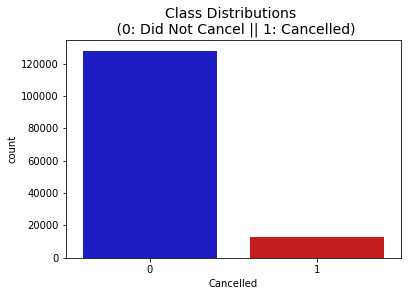

In [6]:
colors = ["#0101DF", "#DF0101"]

sns.countplot('Cancelled', data=df1, palette=colors)
plt.title('Class Distributions \n (0: Did Not Cancel || 1: Cancelled)', fontsize=14);

**12,614 loans cancelled** out of 140,574

This indicates an 'imbalance' in the dataset

In [7]:
df1.describe()

,Cancelled,Default_Charge,Late_Charge,NSF_Charge,Premium,Down,AmtFin,FinChg,APR,Term,...,Agent_RegisteredForCancelListReport,Agent_RegisteredForEimpendingReport,Agent_RecurringACHForm,Agent_EnrolledInCreditProgram,Agent_DownPaymentViaCC,Agent_DownPaymentViaACH,Borrower_RegisteredOnWeb,Borrower_RegisteredForEForms,Borrower_RegisteredForCancellationWarning,RecurringACH_TF
count,140574.000000,140574.000000,140574.000000,140574.000000,1.405740e+05,1.405740e+05,1.405740e+05,140574.000000,140574.000000,140574.000000,...,140571.000000,140571.000000,140574.000000,140574.000000,140574.000000,140574.000000,140574.000000,140574.000000,140574.000000,140574.000000
mean,0.089732,1.215829,116.388307,1.358726,2.337954e+04,4.597269e+03,1.878227e+04,566.019102,12.300290,9.478140,...,0.116283,0.368696,0.891068,0.799721,0.446875,0.446875,0.260745,0.309282,0.716278,0.008913
std,0.285799,5.881879,722.781218,9.103166,1.206823e+05,2.687509e+04,1.004232e+05,1813.595968,4.533707,1.440692,...,0.320565,0.482453,0.311555,0.400210,0.497171,0.497171,0.439043,0.462199,0.450805,0.093990
min,0.000000,0.000000,-110.600000,0.000000,2.050000e+02,0.000000e+00,3.395000e+01,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,2.138000e+03,4.777000e+02,1.599102e+03,103.610000,8.750000,9.000000,...,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,5.071000e+03,1.108305e+03,3.912495e+03,216.380000,12.250000,10.000000,...,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,0.000000,0.000000,49.460000,0.000000,1.442088e+04,3.000000e+03,1.129574e+04,476.665000,15.350000,10.000000,...,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,1.000000,635.770000,72686.200000,1350.000000,1.486929e+07,2.650548e+06,1.361670e+07,176458.560000,41.000000,36.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
df1.dtypes

Cancelled                                          int64
Loan_Num                                          object
Accepted_Date                                     object
Default_Charge                                   float64
Late_Charge                                      float64
NSF_Charge                                       float64
Premium                                          float64
Down                                             float64
AmtFin                                           float64
FinChg                                           float64
APR                                              float64
Term                                               int64
Mature_Date                                       object
Payments_Rcvd                                      int64
Agent_ID                                           int64
Borrower_ID                                        int64
Borrower_State                                    object
Borrower_Zip                   

In [9]:
df1.isnull().sum()

Cancelled                                             0
Loan_Num                                              0
Accepted_Date                                         0
Default_Charge                                        0
Late_Charge                                           0
NSF_Charge                                            0
Premium                                               0
Down                                                  0
AmtFin                                                0
FinChg                                                0
APR                                                   0
Term                                                  0
Mature_Date                                           0
Payments_Rcvd                                         0
Agent_ID                                              0
Borrower_ID                                           0
Borrower_State                                        0
Borrower_Zip                                    

# Select valuable columns only

In [165]:
df = df1[['Cancelled', 'Accepted_Date', 'Borrower_Classification', 'APR', 'Term', 'Payments_Rcvd', 
          'Borrower_RegisteredOnWeb', 'Borrower_RegisteredForEForms', 'Borrower_RegisteredForCancellationWarning']]
df.head()

,Cancelled,Accepted_Date,Borrower_Classification,APR,Term,Payments_Rcvd,Borrower_RegisteredOnWeb,Borrower_RegisteredForEForms,Borrower_RegisteredForCancellationWarning
0,0,1/6/2015,Services,19.95,9,9,0,0,1
1,0,1/23/2015,Real Estate,10.65,10,10,0,0,1
2,0,1/23/2015,Transportation,14.00,10,10,0,0,1
3,0,1/26/2015,General,14.50,9,9,0,0,0
4,0,2/9/2015,Construction,23.95,9,9,0,1,1


In [79]:
df.dtypes

Cancelled                                      int64
Accepted_Date                                 object
Borrower_Classification                       object
APR                                          float64
Term                                           int64
Payments_Rcvd                                  int64
Borrower_RegisteredOnWeb                       int64
Borrower_RegisteredForEForms                   int64
Borrower_RegisteredForCancellationWarning      int64
dtype: object

In [80]:
df.isnull().sum()

Cancelled                                    0
Accepted_Date                                0
Borrower_Classification                      0
APR                                          0
Term                                         0
Payments_Rcvd                                0
Borrower_RegisteredOnWeb                     0
Borrower_RegisteredForEForms                 0
Borrower_RegisteredForCancellationWarning    0
dtype: int64

In [61]:
df.describe()

,Cancelled,APR,Term,Payments_Rcvd,Borrower_RegisteredOnWeb,Borrower_RegisteredForEForms,Borrower_RegisteredForCancellationWarning
count,140574.000000,140574.000000,140574.000000,140574.000000,140574.000000,140574.000000,140574.000000
mean,0.089732,12.300290,9.478140,8.437371,0.260745,0.309282,0.716278
std,0.285799,4.533707,1.440692,2.841458,0.439043,0.462199,0.450805
min,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,8.750000,9.000000,9.000000,0.000000,0.000000,0.000000
50%,0.000000,12.250000,10.000000,10.000000,0.000000,0.000000,1.000000
75%,0.000000,15.350000,10.000000,10.000000,1.000000,1.000000,1.000000
max,1.000000,41.000000,36.000000,24.000000,1.000000,1.000000,1.000000


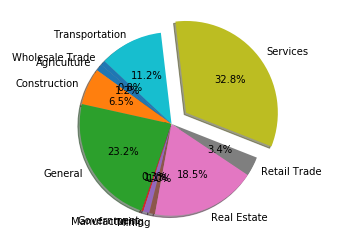

In [158]:
# pie plot
g = df.groupby('Borrower_Classification').size().reset_index()
explode = (0, 0, 0, 0, 0, 0, 0, 0, 0.2, 0, 0)  # explode 1st slice

plt.pie(g[0], labels=g['Borrower_Classification'], explode=explode, autopct='%1.1f%%', shadow=True, startangle=140)

plt.axis('equal');

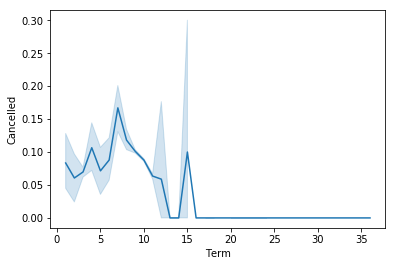

In [183]:
sns.lineplot(x="Term", y="Cancelled", data=df);

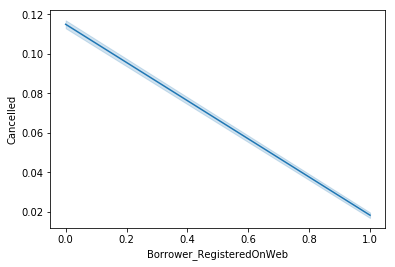

In [182]:
sns.lineplot(x="Borrower_RegisteredOnWeb", y="Cancelled", data=df);

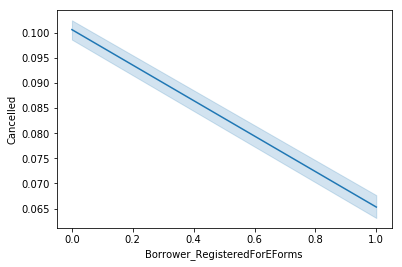

In [181]:
sns.lineplot(x="Borrower_RegisteredForEForms", y="Cancelled", data=df);

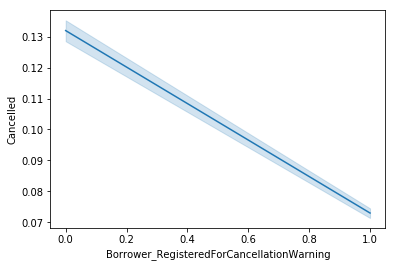

In [180]:
sns.lineplot(x="Borrower_RegisteredForCancellationWarning", y="Cancelled", data=df);

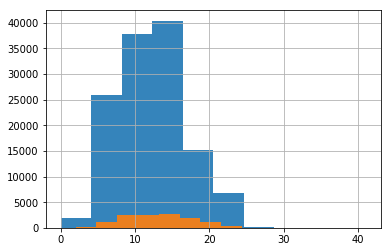

In [169]:
df.groupby('Cancelled').APR.hist(alpha=0.9);

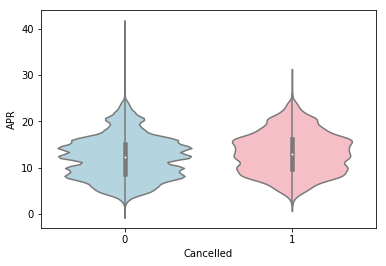

In [179]:
sns.violinplot("Cancelled", "APR", data=df,
               palette=["lightblue", "lightpink"]);

In [170]:
# convert 'Accepted_Date' to datetime, create new column with 'Accepted_Date' values converted to months(int), create dummy variables for 'accepted_month'(0-11)(12 months)
#  and finally drop orignal column

df['Accepted_Date'] = pd.to_datetime(df['Accepted_Date'])
df['accepted_month'] = df['Accepted_Date'].dt.month
df = pd.get_dummies(df, columns=['accepted_month'], prefix=['accepted_month'])
df = df.drop(['Accepted_Date'], axis=1)
df.head(1)

,Cancelled,Borrower_Classification,APR,Term,Payments_Rcvd,Borrower_RegisteredOnWeb,Borrower_RegisteredForEForms,Borrower_RegisteredForCancellationWarning,accepted_month_1,accepted_month_2,accepted_month_3,accepted_month_4,accepted_month_5,accepted_month_6,accepted_month_7,accepted_month_8,accepted_month_9,accepted_month_10,accepted_month_11,accepted_month_12
0,0,Services,19.95,9,9,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0


In [82]:
df.tail(1)

,Cancelled,Borrower_Classification,APR,Term,Payments_Rcvd,Borrower_RegisteredOnWeb,Borrower_RegisteredForEForms,Borrower_RegisteredForCancellationWarning,accepted_month_1,accepted_month_2,accepted_month_3,accepted_month_4,accepted_month_5,accepted_month_6,accepted_month_7,accepted_month_8,accepted_month_9,accepted_month_10,accepted_month_11,accepted_month_12
140573,1,General,19.35,10,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [83]:
df.shape

(140574, 20)

## Visualize Correlation between 'Borrower_Classification' dummy variables and 'Cancelled'

In [152]:
# Create new Dataframe so that we can more easily visualize 'Borrower_Classification' dummy variables before we perform mapping and replacing

df2 = df1[['Cancelled', 'Accepted_Date', 'Borrower_Classification', 'APR', 'Term', 'Payments_Rcvd', 
          'Borrower_RegisteredOnWeb', 'Borrower_RegisteredForEForms', 'Borrower_RegisteredForCancellationWarning']]
df2['Accepted_Date'] = pd.to_datetime(df2['Accepted_Date'])
df2['accepted_month'] = df2['Accepted_Date'].dt.month
df2 = pd.get_dummies(df2, columns=['accepted_month'], prefix=['accepted_month'])
df2 = df2.drop(['Accepted_Date'], axis=1)
df2 = pd.get_dummies(df2, columns=['Borrower_Classification'], prefix=['Borrower_Classification'])

In [153]:
corr = pd.DataFrame(df2.corr()['Cancelled'].drop('Cancelled'))
corr.sort_values(['Cancelled'], ascending = False)

,Cancelled
Borrower_Classification_Transportation,0.084080
APR,0.063300
Borrower_Classification_General,0.024345
Borrower_Classification_Construction,0.021187
Borrower_Classification_Retail Trade,0.009292
accepted_month_8,0.006763
accepted_month_10,0.005289
Borrower_Classification_Mining,0.003310
accepted_month_5,0.001973
accepted_month_3,0.001345


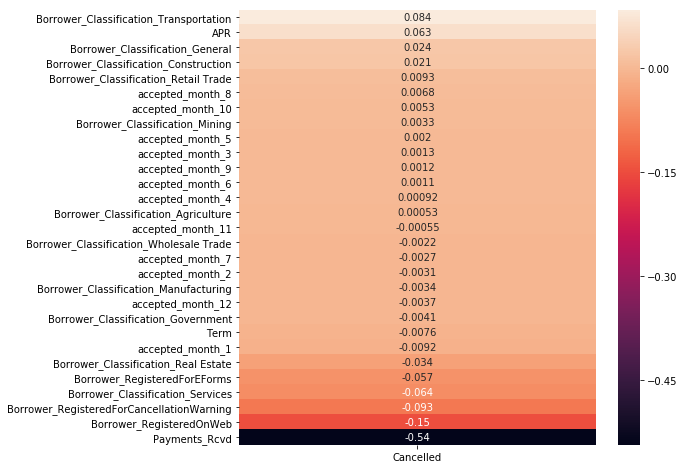

In [154]:
# heatmap for correlation
plt.figure(figsize=(8,8))
sns.heatmap(corr.sort_values(['Cancelled'], ascending = False), annot=True);

In [171]:
#mappling or replacing
df = df.replace({'Borrower_Classification': 'Services'}, {'Borrower_Classification': '0'})
df = df.replace({'Borrower_Classification': 'General'}, {'Borrower_Classification': '1'})
df = df.replace({'Borrower_Classification': 'Real Estate'}, {'Borrower_Classification': '2'})
df = df.replace({'Borrower_Classification': 'Transportation'}, {'Borrower_Classification': '3'})
df = df.replace({'Borrower_Classification': 'Construction'}, {'Borrower_Classification': '4'})
df = df.replace({'Borrower_Classification': 'Retail Trade'}, {'Borrower_Classification': '5'})
df = df.replace({'Borrower_Classification': 'Agriculture'}, {'Borrower_Classification': '6'})
df = df.replace({'Borrower_Classification': 'Manufacturing'}, {'Borrower_Classification': '7'})
df = df.replace({'Borrower_Classification': 'Mining'}, {'Borrower_Classification': '8'})
df = df.replace({'Borrower_Classification': 'Wholesale Trade'}, {'Borrower_Classification': '9'})
df = df.replace({'Borrower_Classification': 'Government'}, {'Borrower_Classification': '10'})

In [124]:
df['Borrower_Classification'].value_counts()

0     46160
1     32578
2     26026
3     15727
4      9090
5      4774
6      1657
7      1484
8      1423
9      1192
10      463
Name: Borrower_Classification, dtype: int64

**Borrower_Classification:**
    - Services = 0
    - General = 1
    - Real Estate = 2
    - Transportation = 3
    - Construction = 4
    - Retail Trade = 5
    - Agriculture = 6
    - Manufacturing = 7
    - Mining = 8
    - Wholesale Trade = 9
    - Government = 10

In [172]:
# convert object to number
df['Borrower_Classification'] = df['Borrower_Classification'].astype(int)
df.dtypes

Cancelled                                      int64
Borrower_Classification                        int32
APR                                          float64
Term                                           int64
Payments_Rcvd                                  int64
Borrower_RegisteredOnWeb                       int64
Borrower_RegisteredForEForms                   int64
Borrower_RegisteredForCancellationWarning      int64
accepted_month_1                               uint8
accepted_month_2                               uint8
accepted_month_3                               uint8
accepted_month_4                               uint8
accepted_month_5                               uint8
accepted_month_6                               uint8
accepted_month_7                               uint8
accepted_month_8                               uint8
accepted_month_9                               uint8
accepted_month_10                              uint8
accepted_month_11                             

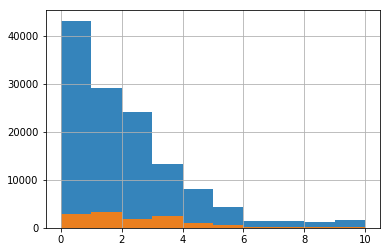

In [174]:
df.groupby('Cancelled').Borrower_Classification.hist(alpha=0.9);

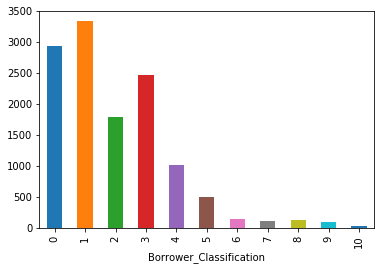

In [177]:
df.groupby('Borrower_Classification')['Cancelled'].sum().plot.bar();

In [126]:
df = pd.get_dummies(df, columns=['Borrower_Classification'], prefix=['Borrower_Classification'])
df.head(1)

,Cancelled,APR,Term,Payments_Rcvd,Borrower_RegisteredOnWeb,Borrower_RegisteredForEForms,Borrower_RegisteredForCancellationWarning,accepted_month_1,accepted_month_2,accepted_month_3,...,Borrower_Classification_1,Borrower_Classification_2,Borrower_Classification_3,Borrower_Classification_4,Borrower_Classification_5,Borrower_Classification_6,Borrower_Classification_7,Borrower_Classification_8,Borrower_Classification_9,Borrower_Classification_10
0,0,19.95,9,9,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [159]:
df.tail(1)

,Cancelled,APR,Term,Payments_Rcvd,Borrower_RegisteredOnWeb,Borrower_RegisteredForEForms,Borrower_RegisteredForCancellationWarning,accepted_month_1,accepted_month_2,accepted_month_3,...,Borrower_Classification_1,Borrower_Classification_2,Borrower_Classification_3,Borrower_Classification_4,Borrower_Classification_5,Borrower_Classification_6,Borrower_Classification_7,Borrower_Classification_8,Borrower_Classification_9,Borrower_Classification_10
140573,1,19.35,10,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


# Import and manipulate 'Test data'

In [143]:
test1 = pd.read_csv('Test_Data.csv')
test1.head(1)

,Cancelled,Loan_Num,Accepted_Date,Default_Charge,Late_Charge,NSF_Charge,Premium,Down,AmtFin,FinChg,...,Borrower_RegisteredForEForms,Borrower_DateRegisteredForEForms,Borrower_RegisteredForCancellationWarning,Borrower_DATERegisteredForCancellationWarning,Borrower_Classification,Borrower_SubTerm,Risk_Score,NoticeOfIntentToCancelDate,BankruptcyFlag,RecurringACH_TF
0,0,E98E3CF6-E1CA-49A5-A309-E012B71F8BAF,10/31/2016,0.0,0.0,0.0,40240.2,10060.05,30180.15,902.43,...,0,NaN,1,8/19/2016,Services,General Services,A,NaN,NaN,False


In [144]:
test = test1[['Cancelled', 'Accepted_Date', 'Borrower_Classification', 'APR', 'Term', 'Payments_Rcvd', 
          'Borrower_RegisteredOnWeb', 'Borrower_RegisteredForEForms', 'Borrower_RegisteredForCancellationWarning']]
test['Accepted_Date'] = pd.to_datetime(test['Accepted_Date'])
test['accepted_month'] = test['Accepted_Date'].dt.month
test = pd.get_dummies(test, columns=['accepted_month'], prefix=['accepted_month'])
test = test.drop(['Accepted_Date'], axis=1)

In [145]:
#mappling or replacing
test = test.replace({'Borrower_Classification': 'Services'}, {'Borrower_Classification': '0'})
test = test.replace({'Borrower_Classification': 'General'}, {'Borrower_Classification': '1'})
test = test.replace({'Borrower_Classification': 'Real Estate'}, {'Borrower_Classification': '2'})
test = test.replace({'Borrower_Classification': 'Transportation'}, {'Borrower_Classification': '3'})
test = test.replace({'Borrower_Classification': 'Construction'}, {'Borrower_Classification': '4'})
test = test.replace({'Borrower_Classification': 'Retail Trade'}, {'Borrower_Classification': '5'})
test = test.replace({'Borrower_Classification': 'Agriculture'}, {'Borrower_Classification': '6'})
test = test.replace({'Borrower_Classification': 'Manufacturing'}, {'Borrower_Classification': '7'})
test = test.replace({'Borrower_Classification': 'Mining'}, {'Borrower_Classification': '8'})
test = test.replace({'Borrower_Classification': 'Wholesale Trade'}, {'Borrower_Classification': '9'})
test = test.replace({'Borrower_Classification': 'Government'}, {'Borrower_Classification': '10'})

In [146]:
# convert object to number and create dummy variables
test['Borrower_Classification'] = test['Borrower_Classification'].astype(int)
test = pd.get_dummies(test, columns=['Borrower_Classification'], prefix=['Borrower_Classification'])

In [165]:
test.dtypes

Cancelled                                      int64
APR                                          float64
Term                                           int64
Payments_Rcvd                                  int64
Borrower_RegisteredOnWeb                       int64
Borrower_RegisteredForEForms                   int64
Borrower_RegisteredForCancellationWarning      int64
accepted_month_1                               uint8
accepted_month_2                               uint8
accepted_month_3                               uint8
accepted_month_4                               uint8
accepted_month_5                               uint8
accepted_month_6                               uint8
accepted_month_7                               uint8
accepted_month_8                               uint8
accepted_month_9                               uint8
accepted_month_10                              uint8
accepted_month_11                              uint8
accepted_month_12                             

In [147]:
# save test data
test.to_csv("my_test_data.csv", index=False)

# Build models

In [131]:
y_train = df['Cancelled']
y_test = test['Cancelled']
X_train = df.drop(['Cancelled'], axis=1)
X_test = test.drop(['Cancelled'], axis=1)

In [132]:
print(X_train.shape, X_test.shape)

(140574, 29) (42172, 29)


In [133]:
# Let's implement simple classifiers

classifiers = {
    "LogisiticRegression": LogisticRegression(),
    "KNearest": KNeighborsClassifier(),
    "Support Vector Classifier": SVC(),
    "DecisionTreeClassifier": DecisionTreeClassifier(),
    "RandomForestClassifier": RandomForestClassifier(n_estimators=100)
}

In [134]:
for key, classifier in classifiers.items():
    classifier.fit(X_train, y_train)
    y_score = classifier.predict(X_test)
    print(key)
    print(accuracy_score(y_test, y_score))
    print(confusion_matrix(y_test, y_score))
    print(classification_report(y_test, y_score))
    print("recall score:", recall_score(y_test, y_score))
    average_precision = average_precision_score(y_test, y_score)
    print('Average precision-recall score: {0:0.2f}'.format(average_precision))
    print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")

LogisiticRegression
0.9250213411742388
[[37310  1069]
 [ 2093  1700]]
              precision    recall  f1-score   support

           0       0.95      0.97      0.96     38379
           1       0.61      0.45      0.52      3793

   micro avg       0.93      0.93      0.93     42172
   macro avg       0.78      0.71      0.74     42172
weighted avg       0.92      0.93      0.92     42172

recall score: 0.4481940416556815
Average precision-recall score: 0.32
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
KNearest
0.9463862278288913
[[37439   940]
 [ 1321  2472]]
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     38379
           1       0.72      0.65      0.69      3793

   micro avg       0.95      0.95      0.95     42172
   macro avg       0.85      0.81      0.83     42172
weighted avg       0.94      0.95      0.95     42172

recall score: 0.6517268652781439
Average precision-recall score: 0.50
+++

- RandomForestClassifier seems to be the most accurate and effective model

# Deal with oversampling by using SMOTE

In [136]:
os = SMOTE(random_state=0)
columns = X_train.columns

os_data_X,os_data_y=os.fit_sample(X_train, y_train)
os_data_X = pd.DataFrame(data=os_data_X,columns=columns )
os_data_y= pd.DataFrame(data=os_data_y,columns=['y'])

# we can Check the numbers of our data
print("length of oversampled data is ",len(os_data_X))
print("Number of No Cancel in oversampled data",len(os_data_y[os_data_y['y']==0]))
print("Number of Cancelled",len(os_data_y[os_data_y['y']==1]))
print("Proportion of No Cancel data in oversampled data is ",len(os_data_y[os_data_y['y']==0])/len(os_data_X))
print("Proportion of Cancelled data in oversampled data is ",len(os_data_y[os_data_y['y']==1])/len(os_data_X))

length of oversampled data is  255920
Number of No Cancel in oversampled data 127960
Number of Cancelled 127960
Proportion of No Cancel data in oversampled data is  0.5
Proportion of Cancelled data in oversampled data is  0.5


In [137]:
print(os_data_X.shape, os_data_y.shape)

(255920, 29) (255920, 1)


In [138]:
os_data_y['y'].value_counts()

1    127960
0    127960
Name: y, dtype: int64

In [139]:
print(X_test.shape, y_test.shape)

(42172, 29) (42172,)


## Model building w/ the oversampling data

In [140]:
classifiers = {
    "RandomForestClassifier": RandomForestClassifier(n_estimators=100)    
}

In [141]:
for key, classifier in classifiers.items():
    classifier.fit(os_data_X, os_data_y)
    y_score = classifier.predict(X_test)
    print(key)
    print(accuracy_score(y_test, y_score))
    print(confusion_matrix(y_test, y_score))
    print(classification_report(y_test, y_score))
    print(recall_score(y_test, y_score))
    average_precision = average_precision_score(y_test, y_score)
    print('Average precision-recall score: {0:0.2f}'.format(average_precision))
    print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")

RandomForestClassifier
0.9977236080811913
[[38319    60]
 [   36  3757]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     38379
           1       0.98      0.99      0.99      3793

   micro avg       1.00      1.00      1.00     42172
   macro avg       0.99      0.99      0.99     42172
weighted avg       1.00      1.00      1.00     42172

0.9905088320590562
Average precision-recall score: 0.98
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


In [142]:
# Save model
joblib.dump(classifier, open('InvictaModel.pkl', 'wb'))

# Findings

- Most of the loan customers completed the terms of their without it being cancelled prematurely.
- We can see a trend that as a loan’s term approaches around 8 months, the likelihood of a borrower cancelling their loan increases. If you continue past 8 months the percentage of cancelled loans begins to decrease, however it spikes up once again at around 15 months. If we take everything into account here, we could determine that borrowers are more likely to cancel their loan if their term is shorter. A loan with a term longer than 15 months is very unlikely to be cancelled. On the other hand, loans that are between 0 and 10 months are much more likely to be cancelled.
- We can infer that there is a very strong correlation between clients in the “Transportation” borrower classification and those who have “Cancelled” their loans. APR is also very highly correlated with those who have “Cancelled” their loans.
- You can see that a higher percentage of borrowers who did not register for the web have cancelled their loan. Around 12% of those who did not register, cancelled their loan. On the other hand, the borrowers who registered were very unlikely to cancel their loan. Only about 2% of borrowers who registered ended up cancelling their loans. From this it can be gathered that a buyer who registers on the web is far less likely to cancel on a loan. 
- Overall, our RandomForest model was the most accurate with a recall score of 0.99. Even though this model is not perfect I believe that it could be used to determine whether or not a customer will default on their loans or not.